## Exceptions handling in Python

- exception handling is a fundamental programming concept
- it's essential for building robust and reliable applications


Let's look at:



- What exceptions are why we need to handle them
    - the `EAFP` principle in Python.
- Common Built-in Exceptions - frequently encountered built-in exceptions. 
- handling Exceptions
    - using `try` and `except` blocks. 
    - catching specific exceptions. 
    - the `else` and `finally` clauses.
- raising exceptions
- creating custom exceptions. 
    - when and why to raise exceptions.
- best practices for exception handling
    - error messages and traceback. 
    - logging exceptions for debugging. 
    - defensive programming techniques.
- advanced techniques
    - exception chaining and re-raising exceptions. 
    - using context managers for resource handling and exceptions.
- exception hierarchies
    - understanding the Python exception hierarchy.

### What are exceptions?
- an exception is an event or error condition that interrupts the normal flow of program execution. 
- raised when something unexpected or exceptional occurs. 
    - examples - a division by zero, an attempt to open a non-existent file, or an out-of-range list index.

### Why we need  to handle exceptions

- allows you to gracefully respond to errors, preventing your program from crashing when something goes wrong.
- to provide valuable information about the cause of an error, making it easier to diagnose and fix issues during development.
-  to ensure your program can handle unexpected situations and continues functioning as expected.


### The EAFP Principle in Python
- `EAFP` - Easier to Ask for Forgiveness than Permission
     - Python's approach to handling exceptions
     - encourages writing code that assumes something will work and handles exceptions if it doesn't, rather than checking for conditions beforehand.
     
 See example of EAFP principle below:

In [1]:
# EAFP Approach 
try: 
    result = 10 / 0 # Attempt a division by zero 
except ZeroDivisionError as e: 
    print(f"An error occurred: {e}")

An error occurred: division by zero


**Reflecting on the code snippet above**

- we attempt to divide by zero without checking if the denominator is zero. 
    - if a ZeroDivisionError occurs, we catch it and handle it gracefully.

**Alternative - non-Pythonic approach**:  `LBYL` - Look Before You Leap

    - you would check for zero before performing the division. 
    - EAFP approach is often preferred because it leads to more concise and readable code.

### Common Built-in Exceptions

- `ZeroDivisionError` - Raised when you try to divide by zero.
- `TypeError` - Raised when an operation is performed on an inappropriate data type.
- `ValueError` -  Raised when a function receives an argument of the correct data type but with an inappropriate value.
- `IndexError` - Raised when trying to access an index that is out of range for a sequence 
- `KeyError` - Raised when trying to access a non-existent dictionary key.
- `FileNotFoundError` - Raised when trying to open or manipulate a file that doesn't exist.
- `ImportError` - Raised when an imported module cannot be found.

We now look at some examples:

**Example 1:** `ZeroDivisionError`

In [2]:
try: 
    result = 10 / 0 # Attempt a division by zero 
except ZeroDivisionError as e: 
    print(f"Error: {e}")

Error: division by zero


**Example 2:** `TypeError`


In [3]:
try: 
    result = "5" + 3 # Attempt to concatenate a string and an integer 
except TypeError as e: 
    print(f"Error: {e}")

Error: can only concatenate str (not "int") to str


**Example 3:** `ValueError`


In [4]:
try: 
    num = int("ten") # Attempt to convert an invalid string to an integer 
except ValueError as e: 
    print(f"Error: {e}")

Error: invalid literal for int() with base 10: 'ten'


**Example 4:** `IndexError`

In [5]:
my_list = [1, 2, 3] 
try: 
    element = my_list[3] # Access an index that is out of range 
except IndexError as e: 
    print(f"Error: {e}")

Error: list index out of range


**Example 5:** `KeyError`

In [6]:
my_dict = {"name": "Alice", "age": 30} 
try: 
    value = my_dict["city"] # Access a non-existent key in a dictionary 
except KeyError as e: 
    print(f"Error: {e}")
    

Error: 'city'


**Example 6:** `FileNotFoundError`

In [7]:
try: 
    with open("nonexistent.txt", "r") as file: 
        content = file.read() 
except FileNotFoundError as e: 
    print(f"Error: {e}")

Error: [Errno 2] No such file or directory: 'nonexistent.txt'


**Example 7:** `ImportError`


In [10]:
try: 
    import non_existent_module # Attempt to import a module that doesn't exist 
except ImportError as e: 
    print(f"Error: {e}")

Error: No module named 'non_existent_module'


### Basic Exception handling syntax



In [ ]:
try: 
    # Code that might raise an exception 
except SomeException as e: 
    # Handle the exception

**Thoughts**

- The code inside the try block is executed.
- If an exception occurs within the try block, Python looks for a matching except block.
- If a matching except block is found, its code is executed to handle the exception.
- After the except block is executed, the program continues running as usual.


**Catching Specific Exceptions**

- to do so, specify the exception type in the except block. This allows you to handle different types of exceptions differently.

Example:

In [ ]:
try: 
    result = 10 / 0 # Attempt a division by zero 
except ZeroDivisionError as e: 
    print(f"Error: {e}")

#### Multiple except Blocks
- You can have multiple except blocks to handle different types of exceptions. 
- Python will execute the first matching except block it encounters.

Example:

In [10]:
try: 
    user_input = int(input("Enter a number: ")) 
    result = 10 / user_input 
except ZeroDivisionError as e: 
    print("Error: Cannot divide by zero") 
except ValueError as e: 
    print("Error: Invalid input. Please enter a valid number.")

Enter a number:  s


Error: Invalid input. Please enter a valid number.


**The `else` and `finally` Clauses**

- `else` and `finally` clauses can be used in conjunction with `try` and except `blocks`.
    - `else` block is executed when no exception occurs within the `try` block. 
    - it is often used for code that should run only if no exceptions were raised.
    
- `finally` block is always executed, whether an exception was raised or not.
    - it is commonly used for cleanup code, such as closing files or releasing resources.

In [23]:
try: 
    file = open("example.csv", "r") 
except FileNotFoundError as e: 
    print("Error: File not found") 
else: 
    content = file.read() 
    print("File content:", content) 
finally: 
    file.close() # Always close the file, even if an exception occurred

Error: File not found


### Raising Exceptions
- you can raise your own exceptions when specific conditions are met. 
- useful for signaling errors or exceptional situations within your code.

Example:

In [25]:
class MyCustomError(Exception): 
    pass 

def some_function(): 
    # ... some code ... e.g. 
    error_condition = 3 < 4
    if error_condition: 
        raise MyCustomError("An error occurred due to some condition") 

try: 
    some_function() 
except MyCustomError as e: 
    print(f"Custom error caught: {e}")

Custom error caught: An error occurred due to some condition


### When to Raise Exceptions
-  when you expect to encounter situations where the normal flow of your program cannot proceed due to an error or exceptional condition. 
- use descriptive error messages to help make your code more readable and maintainable.

**Best Practices for Exception Handling**


- obtain information about the error. 
- you can access this information through the exception object. For example:

In [ ]:
try: 
    # Code that might raise an exception 
except SomeException as e: 
    print(f"Error: {e}")
    
    
    # e is the e is the exception object
    
    

- It's good practice to include meaningful error messages in your exceptions.
- Clear and informative error messages help identify the cause of the error quickly. 

Consider including contextual information that can help you debug the problem.

In [26]:
def divide(x, y): 
    if y == 0: 
        raise ValueError("Division by zero is not allowed") 
    return x / y 

try: 
    result = divide(10, 0) 
except ValueError as e: 
    print(f"Error: {e}")
    
# "Division by zero is not allowed" provides context about the specific issue.

Error: Division by zero is not allowed


### Logging Exceptions for Debugging
- Logging is an essential part of debugging and monitoring the behavior of your applications. 
- Python's logging module allows you to log exceptions and other information during program execution.

See Example of logging an exception:

In [11]:
import logging 

logging.basicConfig(filename='app.log', level=logging.ERROR) 

def some_function(): 
    try: 
        # Code that might raise an exception
        result = 5/0
    except Exception as e: 
        logging.error(f"An error occurred: {e}", exc_info=True) 

some_function()

**Reflection on the code**

- we configure logging to write error messages to a file `app.log` and use `logging.ERROR` to log exceptions with detailed traceback information (`exc_info=True`).

- Logging exceptions:
     - helps in identifying errors 
     - provides a history of issues that can be invaluable for debugging.

**Defensive programming techniques**


-  involves writing code that anticipates potential errors and handles them gracefully. 
- minimizes the impact of unexpected issues on your application.

**Some defensive programming techniques include:**

- `Input Validation:` Check and validate user inputs and external data to ensure they meet expected criteria.
- `Boundary Checks:` Perform boundary checks to prevent index errors, buffer overflows, and out-of-range issues.
- `Precondition Checks:` Verify that function preconditions are met before executing the main logic.
- `Graceful Degradation:` Design your code to continue functioning with reduced functionality when certain errors occur.
- `Graceful Handling:` Handle exceptions gracefully by providing fallback mechanisms or alternative paths when errors are encountered.

### Using Context Managers for Resource Handling and Exceptions

- Context managers - often used with the `with` statement
- they simplify resource management and exception handling. 
- they ensure that resources are properly acquired and released, even in the presence of exceptions.

Example:

In [3]:
try: 
    with open('file.txt', 'r') as file: 
         file.read()
except FileNotFoundError as e: 
    print(f"Error: {e}")

Error: [Errno 2] No such file or directory: 'file.txt'


**Notes**

- Using a with statement automatically closes the file when the block is exited, whether by successful execution or due to an exception.
- context managers are useful in situations such as working with database connections


### Exception Hierarchies

- exception hierarchy categorizes and manage exceptions effectively.
- at the top of the hierarchy is the `BaseException` class, which is the base class for all exceptions.
- each specific exception type inherits from a more general exception type. 
    - e.g.  ZeroDivisionError is a subclass of ArithmeticError, which is itself a subclass of Exception.

Understanding the hierarchy allows you to catch broader categories of exceptions when necessary and handle them differently. For instance, you can catch all ArithmeticError exceptions to handle division-related errors collectively.

In [ ]:
try: 
    result = 10 / 0 
except ArithmeticError as e: 
    print(f"Arithmetic Error: {e}")

### Handling Broader Exception Categories
- typically, we catch specific exceptions to handle them in a specialized way
- there are situations where you might want to handle exceptions more broadly. This approach provides a consistent error-handling strategy and simplifies your code.

In [ ]:
try: 
    # Code that might raise various exceptions 
except Exception as e: 
    print(f"An error occurred: {e}")

- Catching Exception allows you to handle any exception that inherits from Exception, which includes nearly all built-in exceptions. 
-  be cautious when using this approach, as it can make it harder to identify and debug specific issues.
- Handling broader exception categories can be useful when you want to ensure that your program continues running gracefully even if unexpected exceptions occur. 
- It's especially valuable in scenarios where you need to log errors, provide informative feedback to users, or take specific actions to recover from errors without knowing their exact nature.

See example of handling broader exceptions to ensure program stability:

In [ ]:
try: 
    # Code that might raise various exceptions 
except Exception as e: 
    log_error(e) # Log the error 
    display_error_message() # Show an error message to the user     
    recover_from_error() # Attempt to recover from the error

### Quick Review - Exception handling syntax
- <b> Unhandled exceptions terminate the program </b>

- Exceptions allow us to deal with runtime errors and unexpected situations, ensuring our programs don’t crash abruptly.

<b>try: </b> <br>
    code body <br>
<b> except </b>[exception_list [as var]]: - executed if exception occurs <br>
    exception handler <br>
<b>else:</b> - not excecuted  if exception occurs <br>
    statements if no exception <br>
<b>finally: </b> - always executed<br>
    final statements
    

- The `try except` block is like a safety net that catches exceptions when they occur, preventing your program from crashing.


- Inside the try block, you write the code that might cause an exception. If an exception occurs, Python jumps to the except block to handle it gracefully, allowing the rest of your program to continue running.

In [6]:
# problem code

result = 10/0

ZeroDivisionError: division by zero

In [5]:
# better
try:
    result = 10 / 0 
except ZeroDivisionError:
    print("Cannot divide by zero!")

Cannot divide by zero!


#### Handling Specific Exceptions
- each except block can catch a specific type of exception. 
- you can provide tailored solutions for different kinds of errors, making your code more resilient.

In [7]:
try:
    file = open("mynotes.txt")
except FileNotFoundError:
    print("File not found!")
except PermissionError:
    print("Permission denied!")

File not found!


In [4]:
# TypeError would be raised if filename was not a string
filename = "foo"
try:
    f = open(filename)
except FileNotFoundError:
    errmsg = filename + " not found"
    print(errmsg)
except (TypeError, ValueError):
    errmsg = "Invalid filename"
    print(errmsg)
if errmsg != "":
    exit(errmsg)
    

foo not found


## Access the exception using the `as` clause

In [5]:
import sys
try:
    f = open("foo")
except FileNotFoundError as err: 
    print("Could not open",err.filename, err.args[1], file=sys.stderr)
    print("Exception arguments:", err.args, file=sys.stderr)

Could not open foo No such file or directory
Exception arguments: (2, 'No such file or directory')


## The finally block
- always executed

In [35]:
def myfunc():
    try:
        f = open("foo")
    finally:
        print("Finally block",
              file=sys.stderr)
try:
    myfunc()
except OSError:
    print("An OS error occurred",
          file=sys.stderr)

Finally block
An OS error occurred


## Order of execution
- Either the except block or the else block is executed before the finally block
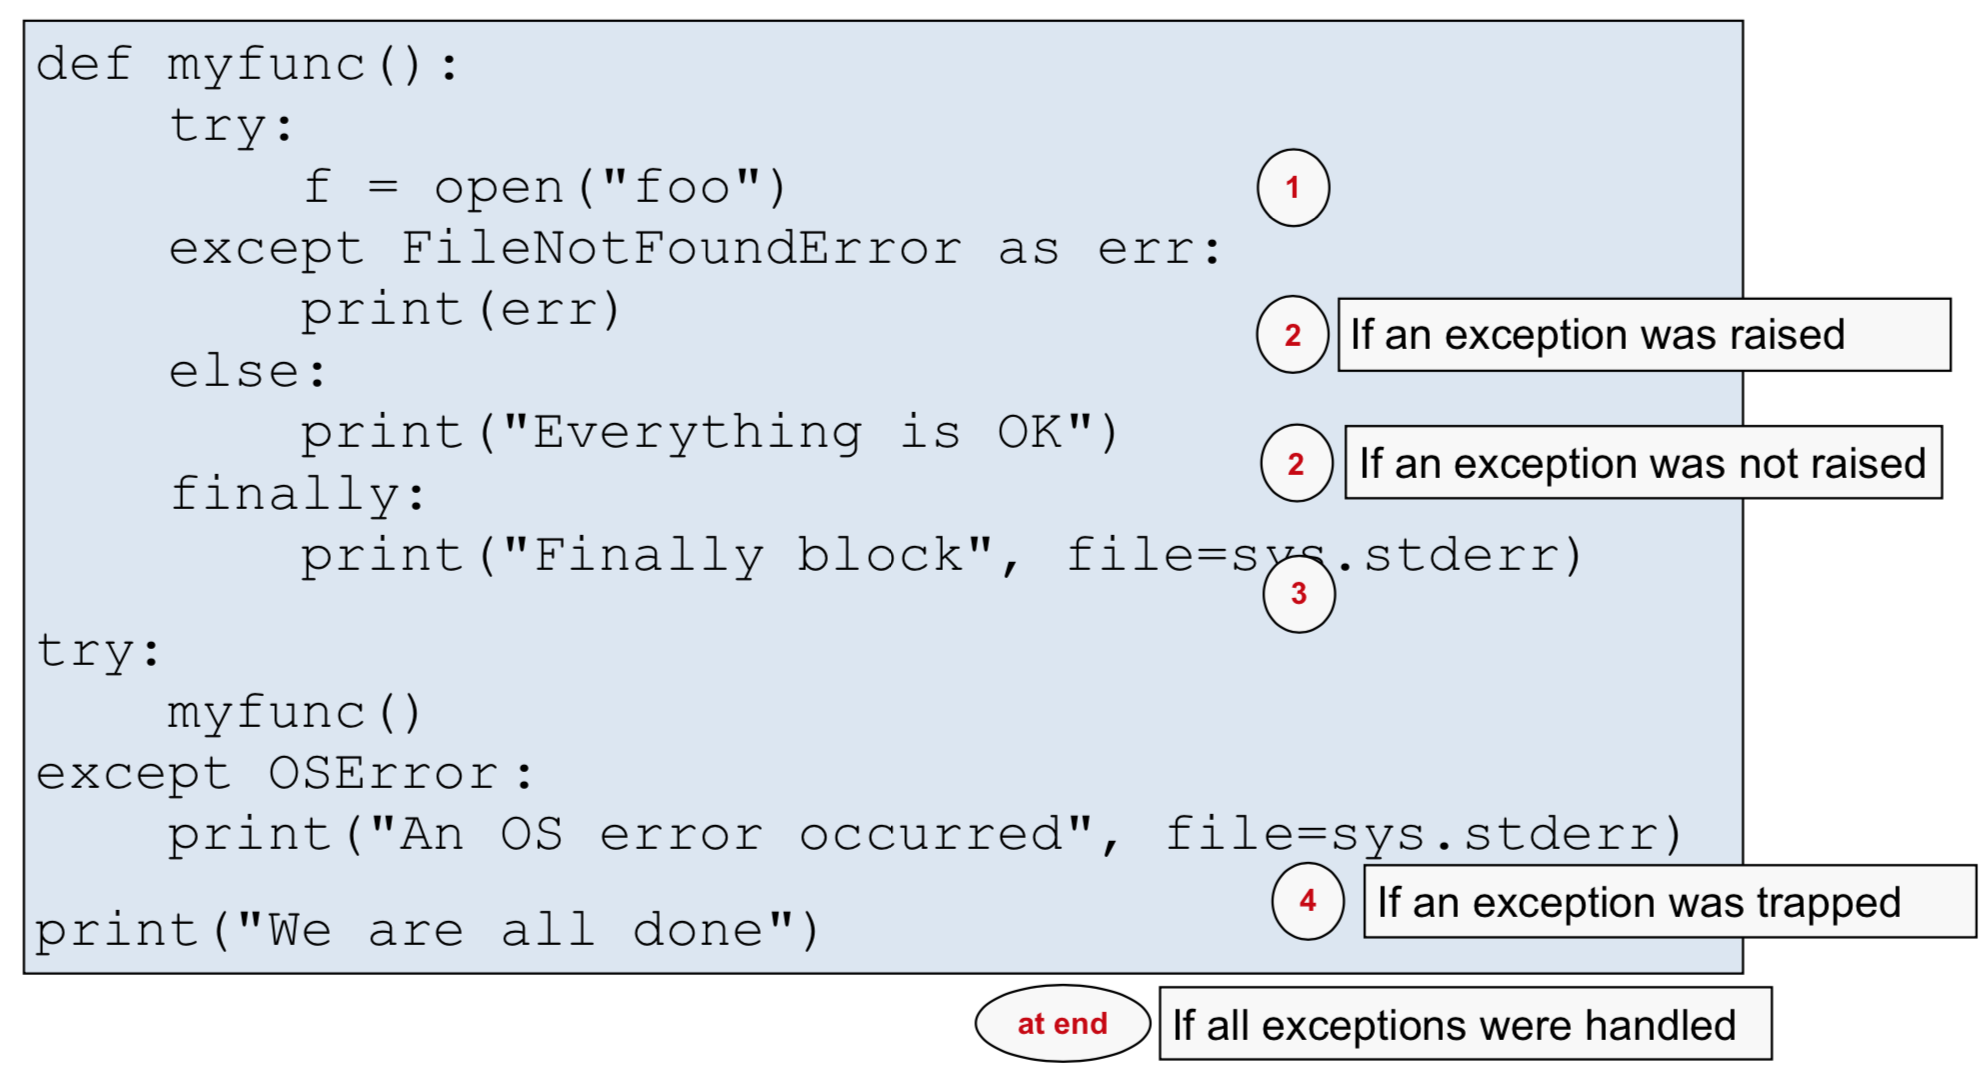

In [6]:
def myfunc():
    
    try:
        f = open("foo.txt") 
    except FileNotFoundError as err:
        print(err)
    else:
        print("Everything is OK")
    finally:
        print("Finally block", file=sys.stderr)
try:
    myfunc()
except OSError:
    print("An OS error occurred", file=sys.stderr)
    print("We are all done")
  

[Errno 2] No such file or directory: 'foo.txt'


Finally block


## The raise statememt

In [7]:
def myfunc(*arguments):
    if not all(arguments):
        raise ValueError("False argument in myfunc")
try:
    myfunc('Tom','',42)
except ValueError as err:
    print("Oops:", err)

Oops: False argument in myfunc


## Define own exceptions 

- by raising exceptions, you can communicate errors or unusual conditions to other parts of your program or to the user, helping them understand what went wrong.



In [8]:
x = -5
if x < 0:
    raise ValueError("Value must be non-negative")

ValueError: Value must be non-negative

In [20]:
class MyError(Exception):
    pass
def myfunc(*arguments):
    if not all(arguments):
        raise MyError("False argument in myfunc")

try:
    myfunc('Tom', '', 42)
except MyError as err:
    print("Oops:", err)

Oops: False argument in myfunc


## printing tracebacks

In [7]:
import sys
try:
    open("some file name")
except FileNotFoundError as err:
    tipe, val, tb = sys.exc_info()
    print("Exception lineno:", tb.tb_lineno)

Exception lineno: 3


In [19]:
# we define a function
# it uses the try..except block
# also uses an Exception handling class
def exampleException():
    try: 
        f = open("test2.txt") 
    except FileNotFoundError as err: 
        print("Could not open", err.filename)
        print("Exception arguments:", err.args,file=sys.stderr)
        
        
exampleException()

Could not open test2.txt


Exception arguments: (2, 'No such file or directory')


In [12]:
def exception2():
    try: 
        f = open("foo") 
    finally:
        print("Finally block", file=sys.stderr)
        
try:
    exception2()
except OSError: 
    print("An OS error occurred", 
          file=sys.stderr)

Finally block
An OS error occurred


### Summary:
- `try`: used to test a block of code for errors. If an error occurs within the try block, Python looks for an except block to handle it.
- `except`: executed if an error occurs within the try block. You can specify which type of exception to catch, allowing for different handling depending on the type of error.
- `finally`: always executed after the try and except blocks, regardless of whether an exception occurred or not. It’s commonly used for cleanup operations, such as closing files or releasing resources.
- `else`: executed if no exceptions are raised in the try block. It provides a way to specify code that should only run if the try block succeeds without any exceptions.